# Import Libraries

In [21]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
import time
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Conv1D, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

# Step 1: Data Collection & Preprocessing

In [ ]:
SYMBOL = 'IBM'
SEED = 100

print(f"Fetching 5 years of unlimited data for {SYMBOL} from Yahoo Finance...")
# yfinance downloads the full dataset instantly, no premium required
df = yf.download(SYMBOL, period='5y')

# Clean up the columns (yfinance sometimes returns a MultiIndex)
if isinstance(df.columns, pd.MultiIndex):
    df_close = df['Close'][[SYMBOL]].rename(columns={SYMBOL: 'Close'})
else:
    df_close = df[['Close']]

# Scale the data for the neural network
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df_close.values)

# Create 60-day sequences
sequence_length = 60
X, y = [], []
for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i, 0])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# Split into 80% Training and 20% Testing
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Data successfully loaded! Total sequences ready for training: {len(X)}")

# Dictionary to store our new time and epoch metrics
training_stats = {}

Fetching 5 years of unlimited data for IBM from Yahoo Finance...


[*********************100%***********************]  1 of 1 completed

Data successfully loaded! Total sequences ready for training: 1196


# STEP 2: MODEL BUILDING & TRAINING

In [23]:
# --- LSTM MODEL ---
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

print("\n--- Training LSTM Model ---")
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')

start_time = time.time() # <-- Start Timer
history_lstm = lstm_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)
lstm_time = time.time() - start_time # <-- End Timer
# Extract exact number of epochs run before early stopping
lstm_epochs = len(history_lstm.history['loss']) 
training_stats['LSTM'] = {'time': lstm_time, 'epochs': lstm_epochs}



--- Training LSTM Model ---
Epoch 1/100


c:\A1 Bukhari\1 UM\Y4 S2\ML\Assignment-FSA1\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 0.0070 - val_loss: 0.0057
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0011 - val_loss: 0.0019
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 8.3885e-04 - val_loss: 0.0018
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 8.0711e-04 - val_loss: 0.0019
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 7.2165e-04 - val_loss: 0.0018
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 6.6524e-04 - val_loss: 0.0017
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 6.0875e-04 - val_loss: 0.0026
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 5.9588e-04 - val_loss: 0.0015
Epoch 9/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 5.1813e-04 - val_loss: 0.0017
Epoch 10/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 5.9932e-04 - val_loss: 0.0018
Epoch 11/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 5.2543e-04 - val_loss: 0.0014
Epoch 12/100
24/24 ━━━━━━━━━

In [24]:
# --- GRU MODEL ---
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

print("\n--- Training GRU Model ---")
gru_model = Sequential([
    GRU(64, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    GRU(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])
gru_model.compile(optimizer='adam', loss='mse')

start_time = time.time() # <-- Start Timer
history_gru = gru_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)
gru_time = time.time() - start_time # <-- End Timer
gru_epochs = len(history_gru.history['loss'])
training_stats['GRU'] = {'time': gru_time, 'epochs': gru_epochs}


--- Training GRU Model ---
Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - loss: 0.0073 - val_loss: 0.0047
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0010 - val_loss: 9.8874e-04
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 7.6762e-04 - val_loss: 0.0010
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 6.6545e-04 - val_loss: 0.0015
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 6.0209e-04 - val_loss: 0.0013
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 5.2912e-04 - val_loss: 0.0010
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 4.5918e-04 - val_loss: 0.0012
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 4.6148e-04 - val_loss: 7.3800e-04
Epoch 9/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 3.9749e-04 - val_loss: 0.0013
Epoch 10/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 3.9871e-04 - val_loss: 8.8138e-04
Epoch 11/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 3.5422

In [ ]:
# --- BIDIRECTIONAL GRU MODEL ---
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

print("\n--- Training Bidirectional GRU Model ---")
bigru_model = Sequential([
    # Wrap the GRU layer in Bidirectional()
    Bidirectional(GRU(64, return_sequences=False), input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

bigru_model.compile(optimizer='adam', loss='mse')

start_time = time.time()
history_bigru = bigru_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)
bigru_time = time.time() - start_time
bigru_epochs = len(history_bigru.history['loss'])
training_stats['BiGRU'] = {'time': bigru_time, 'epochs': bigru_epochs}


--- Training Bidirectional GRU Model ---
Epoch 1/100


c:\A1 Bukhari\1 UM\Y4 S2\ML\Assignment-FSA1\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 0.0080 - val_loss: 0.0304
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0011 - val_loss: 0.0023
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 5.5558e-04 - val_loss: 0.0011
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 4.8877e-04 - val_loss: 8.1345e-04
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 3.4537e-04 - val_loss: 7.4429e-04
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 3.2579e-04 - val_loss: 9.0733e-04
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 3.0716e-04 - val_loss: 7.6785e-04
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 3.4232e-04 - val_loss: 8.7946e-04
Epoch 9/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 2.8237e-04 - val_loss: 8.0708e-04
Epoch 10/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 2.6407e-04 - val_loss: 6.8782e-04
Epoch 11/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 2.2173e-04 - val_loss: 6.8310e

In [26]:
# --- FIXED CNN-GRU Model ---
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

print("\n--- Training CNN-GRU Model ---")
cnn_gru_model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', padding='same', input_shape=(X_train.shape[1], 1)),   
    GRU(64, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

cnn_gru_model.compile(optimizer='adam', loss='mse')

start_time = time.time() # <-- Start Timer
history_cnn_gru = cnn_gru_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32, 
    callbacks=[early_stop], 
    verbose=1
)
cnn_gru_time = time.time() - start_time # <-- End Timer
cnn_gru_epochs = len(history_cnn_gru.history['loss'])
training_stats['CNN-GRU'] = {'time': cnn_gru_time, 'epochs': cnn_gru_epochs}


--- Training CNN-GRU Model ---
Epoch 1/100


c:\A1 Bukhari\1 UM\Y4 S2\ML\Assignment-FSA1\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.0094 - val_loss: 0.0263
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 8.7355e-04 - val_loss: 0.0020
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 4.7913e-04 - val_loss: 0.0014
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 3.8912e-04 - val_loss: 6.8225e-04
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 3.2624e-04 - val_loss: 0.0019
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 3.3951e-04 - val_loss: 0.0010
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 3.1275e-04 - val_loss: 8.1275e-04
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 3.2630e-04 - val_loss: 0.0010
Epoch 9/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 2.7762e-04 - val_loss: 0.0010
Epoch 10/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 2.7698e-04 - val_loss: 6.6308e-04
Epoch 11/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 2.6658e-04 - val_loss: 0.0013
Epoch 12/100

# STEP 3: EVALUATION & SCALING BACK

In [33]:
lstm_pred = lstm_model.predict(X_test, verbose=0)
gru_pred = gru_model.predict(X_test, verbose=0)
bigru_pred = bigru_model.predict(X_test, verbose=0)
cnn_gru_pred = cnn_gru_model.predict(X_test, verbose=0)

# Reverse the 1D scaling directly
y_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
lstm_pred_actual = scaler.inverse_transform(lstm_pred)
gru_pred_actual = scaler.inverse_transform(gru_pred)
bigru_pred_actual = scaler.inverse_transform(bigru_pred)
cnn_gru_pred_actual = scaler.inverse_transform(cnn_gru_pred)

def evaluate(y_true, y_pred, model_name, stats):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{model_name} Performance:")
    print(f"Epochs Run    : {stats['epochs']}")
    print(f"Training Time : {stats['time']:.2f} seconds")
    print(f"Time/Epoch    : {(stats['time'] / stats['epochs']):.2f} seconds/epoch")
    print(f"MAE           : {mae:.2f}")
    print(f"MSE           : {mse:.2f}")
    print(f"RMSE          : {rmse:.2f}")
    print(f"R²            : {r2:.2f}")

evaluate(y_actual, lstm_pred_actual, "LSTM", training_stats['LSTM'])
evaluate(y_actual, gru_pred_actual, "GRU", training_stats['GRU'])
evaluate(y_actual, bigru_pred_actual, "BiGRU", training_stats['BiGRU'])
evaluate(y_actual, cnn_gru_pred_actual, "CNN-GRU", training_stats['CNN-GRU'])


LSTM Performance:
Epochs Run    : 21
Training Time : 19.95 seconds
Time/Epoch    : 0.95 seconds/epoch
MAE           : 9.66
MSE           : 200.40
RMSE          : 14.16
R²            : 0.74

GRU Performance:
Epochs Run    : 29
Training Time : 32.16 seconds
Time/Epoch    : 1.11 seconds/epoch
MAE           : 6.31
MSE           : 91.01
RMSE          : 9.54
R²            : 0.88

BiGRU Performance:
Epochs Run    : 65
Training Time : 61.50 seconds
Time/Epoch    : 0.95 seconds/epoch
MAE           : 5.10
MSE           : 57.04
RMSE          : 7.55
R²            : 0.92

CNN-GRU Performance:
Epochs Run    : 31
Training Time : 25.56 seconds
Time/Epoch    : 0.82 seconds/epoch
MAE           : 5.55
MSE           : 72.82
RMSE          : 8.53
R²            : 0.90


# STEP 4: VISUALIZATION

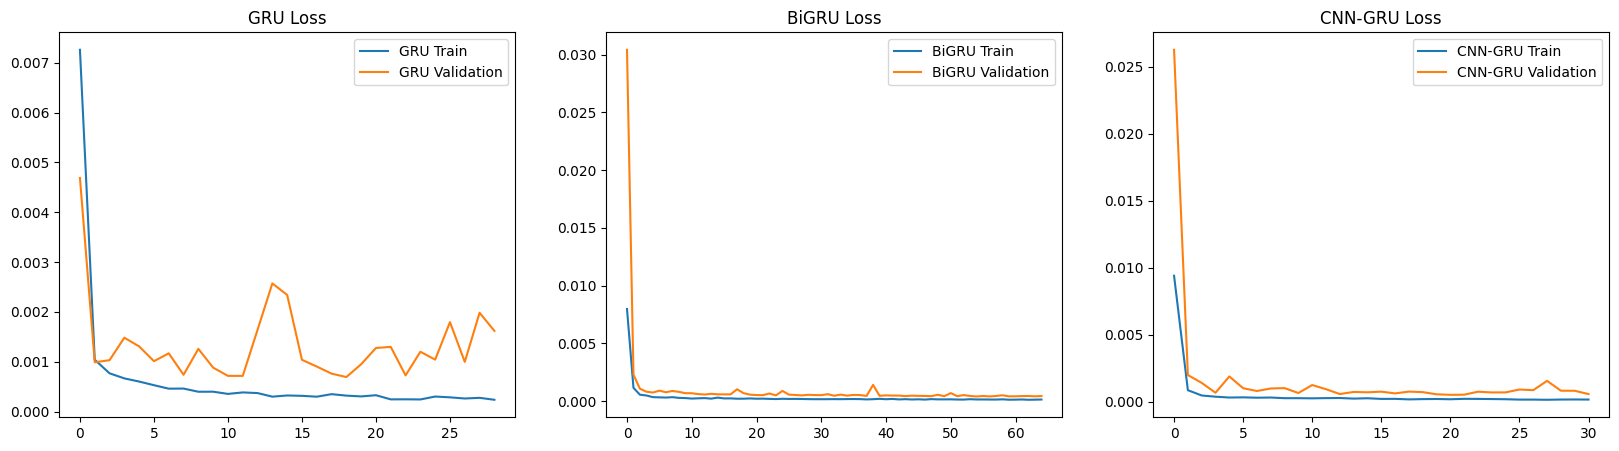

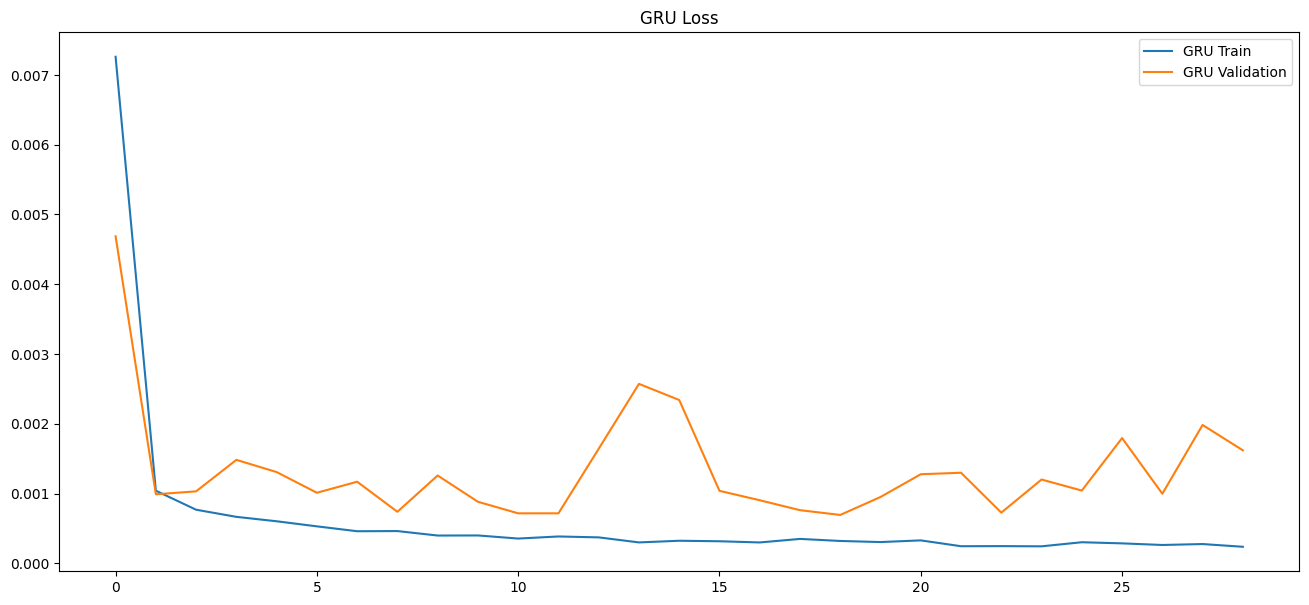

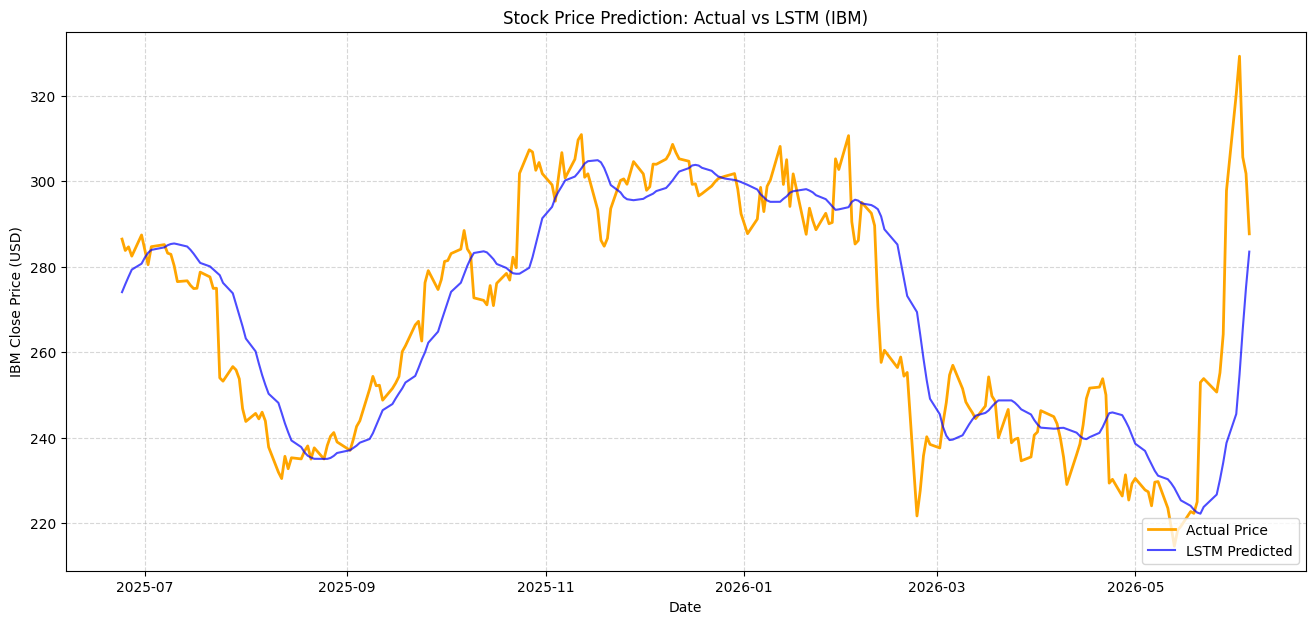

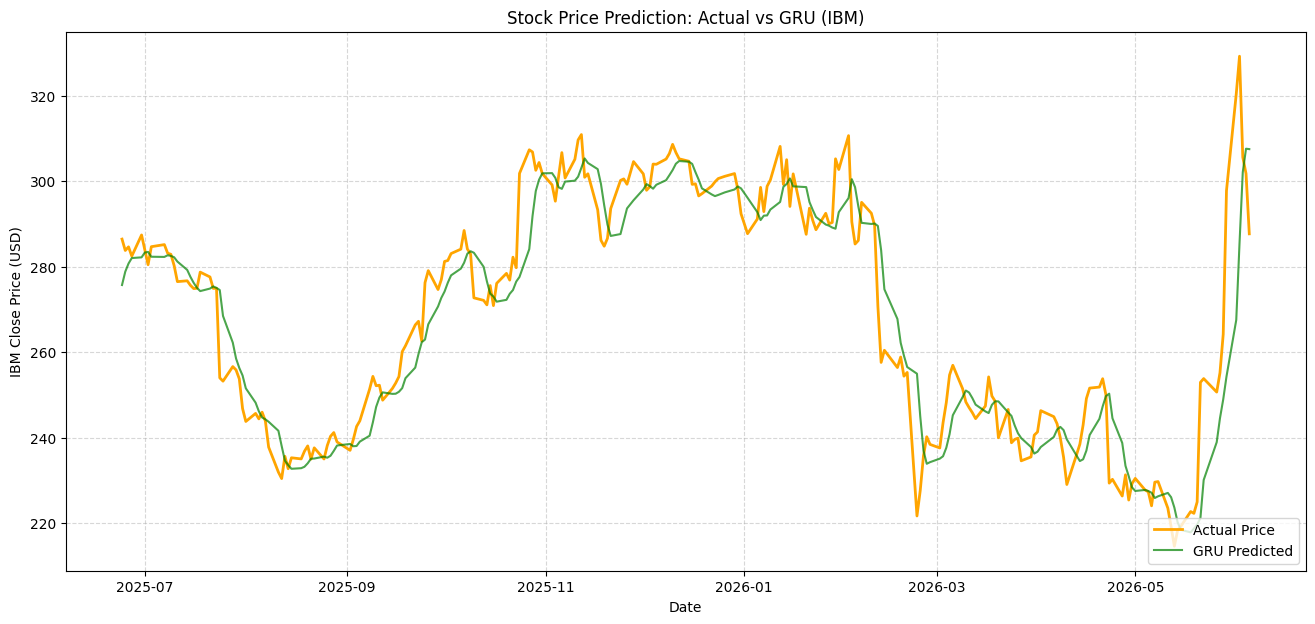

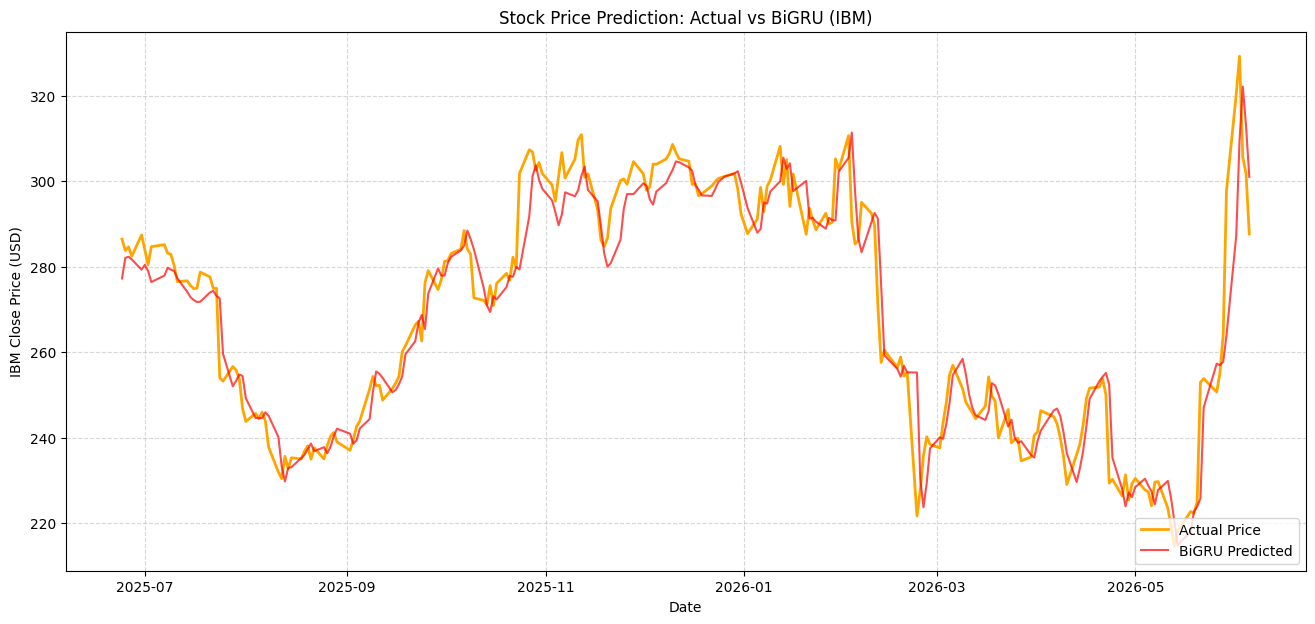

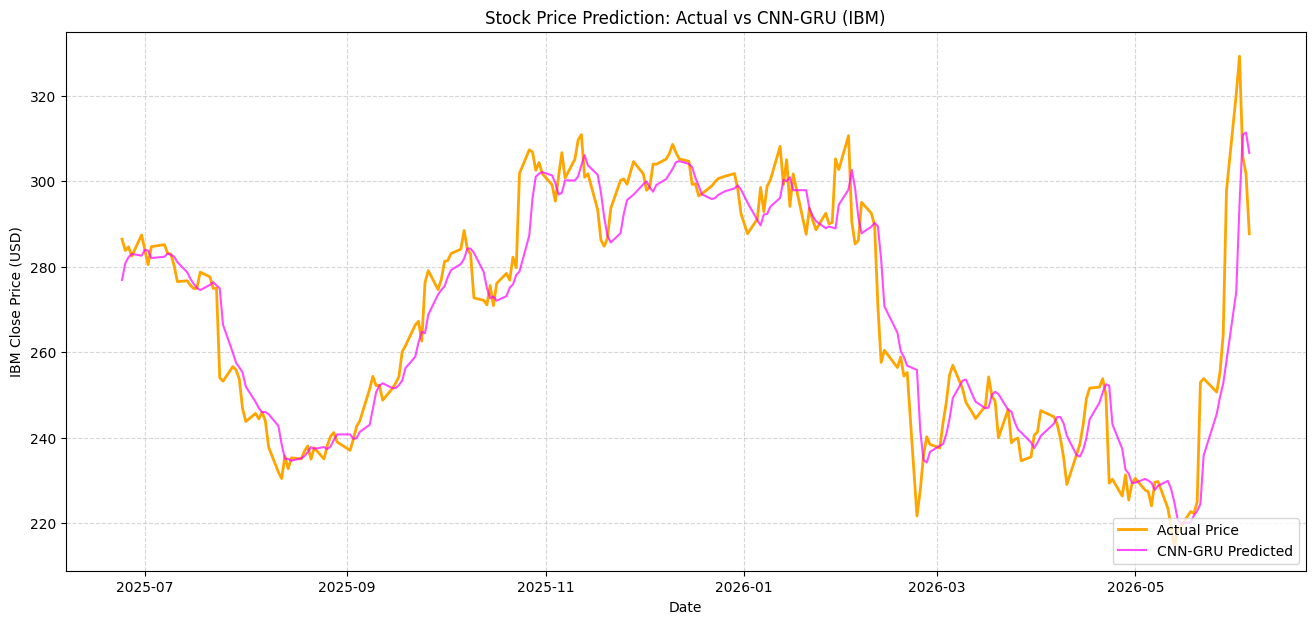

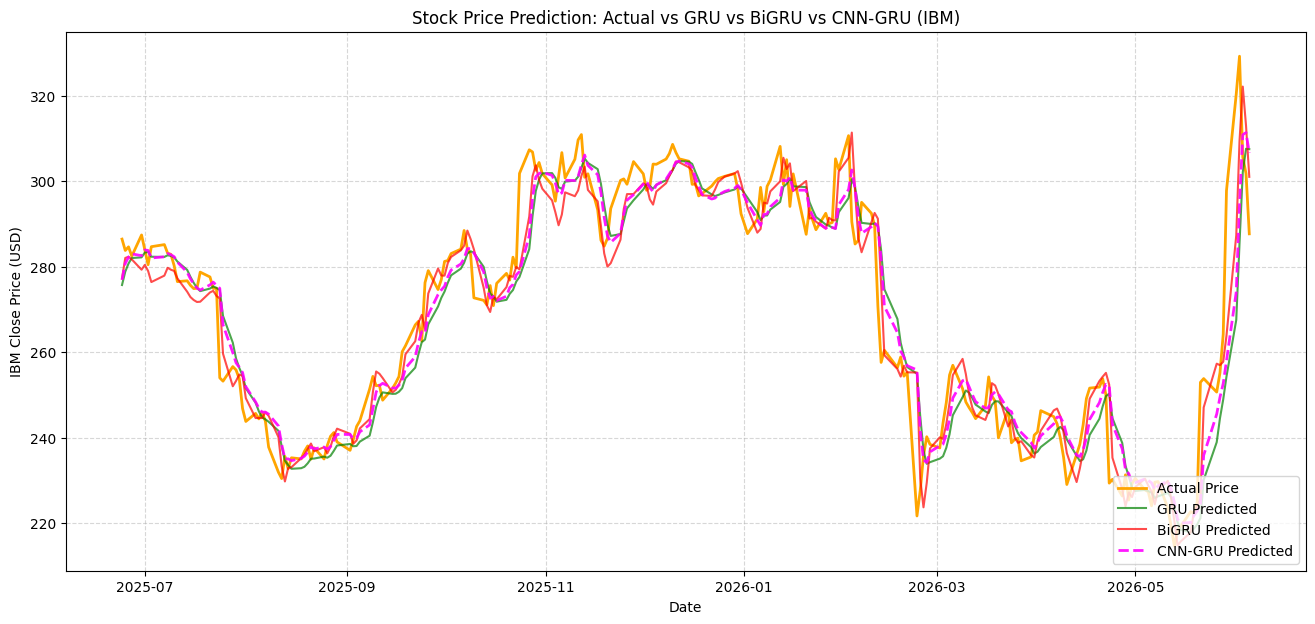

In [34]:
# 1. Loss Curves Comparison
fig, axes = plt.subplots(1,3 , figsize=(20, 5))
axes[0].plot(history_gru.history['loss'], label='GRU Train')
axes[0].plot(history_gru.history['val_loss'], label='GRU Validation')
axes[0].set_title('GRU Loss')
axes[0].legend()

axes[1].plot(history_bigru.history['loss'], label='BiGRU Train')
axes[1].plot(history_bigru.history['val_loss'], label='BiGRU Validation')
axes[1].set_title('BiGRU Loss')
axes[1].legend()

axes[2].plot(history_cnn_gru.history['loss'], label='CNN-GRU Train')
axes[2].plot(history_cnn_gru.history['val_loss'], label='CNN-GRU Validation')
axes[2].set_title('CNN-GRU Loss')
axes[2].legend()

plt.figure(figsize=(16, 7))
plt.plot(history_gru.history['loss'], label='GRU Train')
plt.plot(history_gru.history['val_loss'], label='GRU Validation')
plt.title('GRU Loss')
plt.legend()
plt.show()

# 2. Final Price Prediction Plot
# Extract actual dates for the x-axis
valid_dates = df_close.index[split+sequence_length:]

plt.figure(figsize=(16, 7))
plt.plot(valid_dates, y_actual, label='Actual Price', color='orange', linewidth=2)
plt.plot(valid_dates, lstm_pred_actual, label='LSTM Predicted', color='blue', alpha=0.7)

plt.title(f'Stock Price Prediction: Actual vs LSTM ({SYMBOL})')
plt.xlabel('Date')
plt.ylabel(f'{SYMBOL} Close Price (USD)')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()  


plt.figure(figsize=(16, 7))
plt.plot(valid_dates, y_actual, label='Actual Price', color='orange', linewidth=2)
plt.plot(valid_dates, gru_pred_actual, label='GRU Predicted', color='green', alpha=0.7)

plt.title(f'Stock Price Prediction: Actual vs GRU ({SYMBOL})')
plt.xlabel('Date')
plt.ylabel(f'{SYMBOL} Close Price (USD)')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

plt.figure(figsize=(16, 7))
plt.plot(valid_dates, y_actual, label='Actual Price', color='orange', linewidth=2)
plt.plot(valid_dates, bigru_pred_actual, label='BiGRU Predicted', color='red', alpha=0.7)

plt.title(f'Stock Price Prediction: Actual vs BiGRU ({SYMBOL})')
plt.xlabel('Date')
plt.ylabel(f'{SYMBOL} Close Price (USD)')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()  


plt.figure(figsize=(16, 7))
plt.plot(valid_dates, y_actual, label='Actual Price', color='orange', linewidth=2)
plt.plot(valid_dates, cnn_gru_pred_actual, label='CNN-GRU Predicted', color='magenta', alpha=0.7)

plt.title(f'Stock Price Prediction: Actual vs CNN-GRU ({SYMBOL})')
plt.xlabel('Date')
plt.ylabel(f'{SYMBOL} Close Price (USD)')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


plt.figure(figsize=(16, 7))
plt.plot(valid_dates, y_actual, label='Actual Price', color='orange', linewidth=2)
plt.plot(valid_dates, gru_pred_actual, label='GRU Predicted', color='green', alpha=0.7)
plt.plot(valid_dates, bigru_pred_actual, label='BiGRU Predicted', color='red', alpha=0.7)
plt.plot(valid_dates, cnn_gru_pred_actual, label='CNN-GRU Predicted', color='magenta', alpha=0.9, linewidth=2, linestyle='--')

plt.title(f'Stock Price Prediction: Actual vs GRU vs BiGRU vs CNN-GRU ({SYMBOL})')
plt.xlabel('Date')
plt.ylabel(f'{SYMBOL} Close Price (USD)')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()